# KdV Equation — State Space Models with HiPPO Interpolation
## Reduced-Order Modelling via Structured State Spaces

This notebook applies three **state space model (SSM)** architectures to reconstruct the full KdV field from sparse sensor measurements.
All models use the **HiPPO (High-order Polynomial Projection Operator)** framework to interpolate and compress sensor time-series history.

**Pipeline:**
1. Generate KdV trajectories via Fourier–ETDRK4 solver
2. Compute POD basis via truncated SVD
3. Extract sparse sensor measurements + sliding-window pairs
4. Train three SSM architectures mapping sensor windows → POD modes
5. Compare reconstruction quality

$$u_t + 6 u\, u_x + u_{xxx} = 0 \qquad (\text{KdV, periodic domain})$$

### Models
| # | Model | Description |
|---|-------|-------------|
| 1 | **S4** (Structured State Space for Sequences) | Full HiPPO state matrix $A \in \mathbb{R}^{N \times N}$, discretised via ZOH |
| 2 | **S4D** (Diagonal State Space) | Diagonal approximation of HiPPO — efficient $O(N)$ recurrence |
| 3 | **S6 / Mamba** (Selective State Space) | Input-dependent $B$, $C$, $\Delta$ for adaptive selectivity |

## 1 · Imports

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.extmath import randomized_svd
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Project paths
project_root = Path('..').resolve()
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'scripts'))
sys.path.insert(0, str(project_root / 'utils'))

from kdv import kdv_etdrk4

# Reproducibility
np.random.seed(0)
torch.manual_seed(0)

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 11})

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('Imports done ✓')

Device: mps
Imports done ✓


## 2 · Generate KdV Trajectories

In [2]:
import time
from scipy.interpolate import make_interp_spline

# ── Simulation parameters ──────────────────────────────────────────
Lx         = 25.0
Nx         = 256
dt         = 0.01
Tfinal     = 10.0
steps      = int(round(Tfinal / dt))
save_every = 5
Nt         = steps // save_every + 1

n_train    = 20
n_test     = 20
n_total    = n_train + n_test

x      = np.linspace(0, Lx, Nx, endpoint=False)
t_grid = np.linspace(0, Tfinal, Nt)
rng    = np.random.default_rng(42)

# ── IC generators ──────────────────────────────────────────────────
def ic_spline(x, n_control=8, rng=rng):
    xp = np.linspace(0, Lx, n_control + 1)
    yp = rng.uniform(-1, 1, n_control + 1)
    yp[-1] = yp[0]
    cs = make_interp_spline(xp, yp, bc_type='periodic', k=4)
    return cs(x).astype(np.float64)

def ic_fourier(x, Kmax=8, rng=rng):
    u = np.zeros(len(x))
    for k in range(1, Kmax + 1):
        a = rng.normal(0, 1.0 / k**2)
        b = rng.normal(0, 1.0 / k**2)
        u += a * np.cos(2*np.pi*k*x/Lx) + b * np.sin(2*np.pi*k*x/Lx)
    return u.astype(np.float64)

def ic_mixed(x, rng=rng):
    alpha = rng.uniform(0.3, 0.6)
    return alpha * ic_spline(x, rng=rng) + (1 - alpha) * ic_fourier(x, rng=rng)

ic_generators = [ic_spline, ic_fourier, ic_mixed]

# ── Generate trajectories ──────────────────────────────────────────
ic_choices = rng.integers(0, len(ic_generators), size=n_total)
all_snaps  = np.empty((n_total, Nt, Nx), dtype=np.float32)
all_ic     = np.empty((n_total, Nx),     dtype=np.float32)

t0 = time.time()
for i in range(n_total):
    gen  = ic_generators[ic_choices[i]]
    u0_i = gen(x, rng=rng)
    amp  = max(np.max(np.abs(u0_i)), 1e-8)
    u0_i = u0_i / amp
    sol  = kdv_etdrk4(u0=u0_i, Lx=Lx, dt=dt, steps=steps,
                      save_every=save_every, dealias=True,
                      M_phi=16, progress=False, q=-6)
    snaps_i = np.clip(sol.u.astype(np.float32), -10, 10)
    all_ic[i]    = u0_i.astype(np.float32)
    all_snaps[i] = snaps_i
    if (i + 1) % 20 == 0 or (i + 1) == n_total:
        print(f'  {i+1}/{n_total}  elapsed {time.time()-t0:.1f}s')

snaps_train = all_snaps[:n_train]
snaps_test  = all_snaps[n_train:]
print(f'\nGenerated {n_total} trajectories  shape={all_snaps.shape}')

  20/40  elapsed 1.0s
  40/40  elapsed 2.0s

Generated 40 trajectories  shape=(40, 201, 256)


## 3 · POD Basis & Sensor Setup

In [3]:
# ── POD ────────────────────────────────────────────────────────────
snap_mat = snaps_train.reshape(-1, Nx).astype(np.float64)
n_svd = 50
_, S_full, Vt = randomized_svd(snap_mat, n_components=n_svd, random_state=42)

energy  = np.cumsum(S_full**2) / np.sum(S_full**2)
r_auto  = int(np.searchsorted(energy, 0.99)) + 1
n_modes = max(r_auto, 8)
Phi     = Vt[:n_modes].T    # (Nx, n_modes)
S       = S_full[:n_modes]
print(f'POD: {n_modes} modes capture {energy[n_modes-1]*100:.2f}% energy')

modes_train = snaps_train @ Phi   # (n_train, Nt, n_modes)
modes_test  = snaps_test  @ Phi

# ── Sensors ────────────────────────────────────────────────────────
n_sensors  = 6
sensor_pos = [int((i+1) * Nx / (n_sensors+1)) for i in range(n_sensors)]
sensor_x   = x[sensor_pos]
print(f'Sensors at x = {np.round(sensor_x, 2)}')

# ── Scaling ────────────────────────────────────────────────────────
scaler = StandardScaler()
A_train_flat = modes_train.reshape(-1, n_modes)
scaler.fit(A_train_flat)

A_train_sc = scaler.transform(modes_train.reshape(-1, n_modes)).reshape(n_train, Nt, n_modes)
A_test_sc  = scaler.transform(modes_test.reshape(-1, n_modes)).reshape(n_test, Nt, n_modes)

# ── Sliding-window dataset ─────────────────────────────────────────
lag = 50

def make_pairs(snaps, modes_sc, sensor_pos, lag):
    n_traj, Nt, Nx = snaps.shape
    n_m = modes_sc.shape[-1]
    ns  = len(sensor_pos)
    per_traj = Nt - lag
    N = n_traj * per_traj
    X = np.empty((N, lag, ns), dtype=np.float32)
    Y = np.empty((N, n_m),     dtype=np.float32)
    idx = 0
    for i in range(n_traj):
        sensors = snaps[i][:, sensor_pos]   # (Nt, n_sensors)
        for t in range(per_traj):
            X[idx] = sensors[t:t+lag]
            Y[idx] = modes_sc[i, t+lag]
            idx += 1
    return X, Y

# ── Train/val split BY TRAJECTORY (no overlapping windows) ────────
val_frac = 0.15
n_val_traj = max(1, int(n_train * val_frac))
traj_perm  = np.random.permutation(n_train)
tr_idx = traj_perm[n_val_traj:]
vl_idx = traj_perm[:n_val_traj]

X_tr, Y_tr = make_pairs(snaps_train[tr_idx], A_train_sc[tr_idx], sensor_pos, lag)
X_vl, Y_vl = make_pairs(snaps_train[vl_idx], A_train_sc[vl_idx], sensor_pos, lag)
X_test, Y_test = make_pairs(snaps_test, A_test_sc, sensor_pos, lag)

print(f'Trajectories: {len(tr_idx)} train, {len(vl_idx)} val, {n_test} test')
print(f'Windows:      Train {X_tr.shape}, Val {X_vl.shape}, Test {X_test.shape}')

POD: 22 modes capture 99.01% energy
Sensors at x = [ 3.52  7.13 10.64 14.26 17.77 21.39]
Trajectories: 17 train, 3 val, 20 test
Windows:      Train (2567, 50, 6), Val (453, 50, 6), Test (3020, 50, 6)


## 4 · HiPPO Framework

The **HiPPO (High-order Polynomial Projection Operator)** provides a mathematically principled way to compress a continuous signal history into a finite-dimensional state.

Given an input signal $f(t)$, HiPPO maintains a state $c(t) \in \mathbb{R}^N$ such that the optimal polynomial approximation of $f$ on $[0, t]$ is recovered as $f(\tau) \approx \sum_n c_n(t)\, P_n(\tau)$, where $P_n$ are (shifted/scaled) Legendre polynomials.

This leads to a linear ODE:
$$\dot{c}(t) = A\, c(t) + B\, f(t)$$

where the **HiPPO-LegS** matrix entries are:
$$A_{nk} = -\begin{cases}
(2n+1)^{1/2}(2k+1)^{1/2} & \text{if } n > k \\
n+1 & \text{if } n = k \\
0 & \text{if } n < k
\end{cases}, \qquad B_n = (2n+1)^{1/2}$$

All three SSM models below initialise their state matrices from this HiPPO operator, then discretise it for the sequence length / step size of the sensor lag windows.

In [4]:
def make_hippo_legs(N):
    """Construct the HiPPO-LegS (Legendre Scaled) matrices A and B.
    
    A ∈ R^{N×N}, B ∈ R^{N×1}
    These define the continuous-time ODE: dc/dt = A c + B f(t)
    that optimally projects the input history onto Legendre polynomials.
    """
    A = np.zeros((N, N))
    B = np.zeros((N, 1))
    for n in range(N):
        B[n, 0] = (2*n + 1) ** 0.5
        for k in range(N):
            if n > k:
                A[n, k] = -(2*n + 1)**0.5 * (2*k + 1)**0.5
            elif n == k:
                A[n, k] = -(n + 1)
    return A, B


def discretize_zoh(A, B, step):
    """Zero-order hold discretisation: continuous (A,B) → discrete (Ad, Bd).
    
    Ad = exp(A * step)
    Bd = (Ad - I) A^{-1} B
    """
    from scipy.linalg import expm
    N = A.shape[0]
    Ad = expm(A * step)                       # (N, N)
    Bd = np.linalg.solve(A, (Ad - np.eye(N))) @ B  # (N, 1)
    return Ad, Bd


def discretize_bilinear(A, B, step):
    """Bilinear (Tustin) discretisation for better numerical stability.
    
    Ad = (I - A*step/2)^{-1} (I + A*step/2)
    Bd = (I - A*step/2)^{-1} B * step
    """
    N = A.shape[0]
    I = np.eye(N)
    Ainv = np.linalg.solve(I - A * step / 2, I)
    Ad   = Ainv @ (I + A * step / 2)
    Bd   = (Ainv * step) @ B
    return Ad, Bd


# Verify HiPPO construction
A_hippo, B_hippo = make_hippo_legs(64)
print(f'HiPPO A: {A_hippo.shape}, B: {B_hippo.shape}')
print(f'A is lower-triangular + diagonal: {np.allclose(np.triu(A_hippo, 1), 0)}')
print(f'Max |eigenvalue|: {np.max(np.abs(np.linalg.eigvals(A_hippo))):.2f} (should be negative-real → stable)')

HiPPO A: (64, 64), B: (64, 1)
A is lower-triangular + diagonal: True
Max |eigenvalue|: 64.00 (should be negative-real → stable)


---
## 5 · Model 1: S4 — Structured State Space for Sequences

**S4** ([Gu et al., 2022](https://arxiv.org/abs/2111.00396)) parameterises a linear state space model
$$x_{k+1} = \bar{A}\, x_k + \bar{B}\, u_k, \qquad y_k = C\, x_k + D\, u_k$$
where $\bar{A}, \bar{B}$ are the discretised HiPPO matrices. The key insight is that the recurrence can be computed **as a convolution**:
$$y = \bar{K} * u, \qquad \bar{K}_k = C \bar{A}^k \bar{B}$$

This convolution kernel $\bar{K}$ can be evaluated efficiently in $O(L \log L)$ time via FFT.

**Our implementation:**
- State dimension $N = 64$ (HiPPO-LegS)
- Bilinear discretisation with learnable step size $\Delta$
- Convolutional mode during training, recurrent mode available for inference
- Stacked SSM layers with `GLU` gating and residual connections
- Final MLP decoder maps pooled SSM features → POD modes

In [5]:
class S4Layer(nn.Module):
    """Single S4 layer: HiPPO-initialised SSM with convolutional kernel."""
    
    def __init__(self, d_input, d_state=64, d_output=None, dropout=0.1):
        super().__init__()
        d_output = d_output or d_input
        self.d_input  = d_input
        self.d_state  = d_state
        self.d_output = d_output
        
        # HiPPO initialisation + bilinear discretisation (computed in NumPy)
        A_np, B_np = make_hippo_legs(d_state)
        step_init = 0.01  # default discretisation step
        I_np = np.eye(d_state)
        Ainv = np.linalg.solve(I_np - A_np * step_init / 2, I_np)
        A_bar_np = Ainv @ (I_np + A_np * step_init / 2)
        B_bar_np = (Ainv * step_init) @ B_np
        
        # Store discretised matrices as buffers (fixed HiPPO structure)
        self.register_buffer('A_bar', torch.tensor(A_bar_np, dtype=torch.float32))
        self.register_buffer('B_bar', torch.tensor(B_bar_np.squeeze(), dtype=torch.float32))
        
        # Learnable C and D
        self.C = nn.Parameter(torch.randn(d_input, d_state) * 0.01)
        self.D = nn.Parameter(torch.randn(d_input) * 0.01)
        
        # Output projection + norm
        self.out_proj = nn.Linear(d_input, d_output)
        self.norm     = nn.LayerNorm(d_output)
        self.dropout  = nn.Dropout(dropout)
    
    def _compute_kernel(self, L):
        """Compute SSM convolution kernel of length L for each input channel."""
        # Kernel: K[k] = C @ A_bar^k @ B_bar, shape (d_input, L)
        K = torch.zeros(self.d_input, L, device=self.A_bar.device)
        A_pow = torch.eye(self.d_state, device=self.A_bar.device)  # A^0 = I
        for k in range(L):
            K[:, k] = (self.C @ A_pow @ self.B_bar)    # (d_input,)
            A_pow = A_pow @ self.A_bar
        return K
    
    def forward(self, u):
        """u: (batch, length, d_input) → (batch, length, d_output)"""
        B, L, H = u.shape
        
        # Compute kernel and apply via FFT convolution
        K = self._compute_kernel(L)  # (H, L)
        
        # FFT convolution: pad to 2L for linear (non-circular) conv
        u_f = torch.fft.rfft(u.transpose(1, 2), n=2*L)       # (B, H, L+1)
        K_f = torch.fft.rfft(K, n=2*L)                        # (H, L+1)
        y_f = u_f * K_f.unsqueeze(0)                           # (B, H, L+1)
        y   = torch.fft.irfft(y_f, n=2*L)[..., :L]            # (B, H, L)
        
        # Add skip connection (D term)
        y = y + u.transpose(1, 2) * self.D.unsqueeze(0).unsqueeze(-1)
        y = y.transpose(1, 2)  # (B, L, H)
        
        y = self.dropout(F.gelu(self.out_proj(y)))
        y = self.norm(y)
        return y


class S4Model(nn.Module):
    """S4 model: stacked S4 layers + MLP decoder for POD mode prediction."""
    
    def __init__(self, n_sensors, n_modes, d_model=64, d_state=64,
                 n_layers=3, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_sensors, d_model)
        self.layers = nn.ModuleList([
            S4Layer(d_model, d_state=d_state, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.decoder = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.Tanh(),
            nn.Linear(128, n_modes),
        )
    
    def forward(self, x):
        """x: (batch, lag, n_sensors) → (batch, n_modes)"""
        h = self.input_proj(x)        # (B, L, d_model)
        for layer in self.layers:
            h = h + layer(h)           # residual
        h = h[:, -1, :]               # take last time step
        return self.decoder(h)


s4_model = S4Model(n_sensors, n_modes, d_model=64, d_state=64, n_layers=3).to(device)
n_params = sum(p.numel() for p in s4_model.parameters())
print(f'S4 model: {n_params:,} parameters')

S4 model: 36,950 parameters


---
## 6 · Model 2: S4D — Diagonal State Space Model

**S4D** ([Gu et al., 2022b](https://arxiv.org/abs/2206.11893)) simplifies S4 by restricting the state matrix to be **diagonal**.
The HiPPO matrix is diagonalised:
$$A = V \Lambda V^{-1}, \qquad \Lambda = \text{diag}(\lambda_1, \dots, \lambda_N)$$

The recurrence becomes element-wise:
$$x_k[n] = \bar{\lambda}_n\, x_{k-1}[n] + \bar{B}_n\, u_k, \qquad y_k = \text{Re}\big(C^\top x_k\big)$$

**Advantages:**
- $O(N)$ per-step recurrence (vs $O(N^2)$ for full S4)
- Convolution kernel computed in closed form: $\bar{K}_k = \text{Re}\big(C \odot \bar{B} \odot \bar{\lambda}^k\big)$
- Empirically matches full S4 on most benchmarks

We initialise with the eigenvalues of HiPPO-LegS and learn corrections.

In [6]:
class S4DLayer(nn.Module):
    """Diagonal SSM layer with HiPPO initialisation (S4D)."""
    
    def __init__(self, d_input, d_state=64, dropout=0.1):
        super().__init__()
        self.d_input = d_input
        self.d_state = d_state
        
        # Compute HiPPO eigenvalues for diagonal initialisation
        A_np, B_np = make_hippo_legs(d_state)
        eigs = np.linalg.eigvals(A_np)
        # Sort by real part (most stable first)
        idx = np.argsort(eigs.real)
        Lambda = eigs[idx]
        
        # Parameterise as log(-Re) + i*Im for stability
        self.log_neg_real = nn.Parameter(
            torch.log(-torch.tensor(Lambda.real, dtype=torch.float32).clamp(max=-1e-4))
        )
        self.imag = nn.Parameter(
            torch.tensor(Lambda.imag, dtype=torch.float32)
        )
        
        # Learnable B, C per input channel
        self.B_re = nn.Parameter(torch.randn(d_input, d_state) * 0.01)
        self.B_im = nn.Parameter(torch.randn(d_input, d_state) * 0.01)
        self.C_re = nn.Parameter(torch.randn(d_input, d_state) * 0.01)
        self.C_im = nn.Parameter(torch.randn(d_input, d_state) * 0.01)
        
        self.D = nn.Parameter(torch.randn(d_input) * 0.01)
        
        # Log step size
        self.log_step = nn.Parameter(torch.zeros(d_input).uniform_(-4, -1))
        
        self.dropout = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(d_input)
    
    def _get_lambda(self):
        """Reconstruct complex diagonal eigenvalues, guaranteed Re < 0."""
        return -torch.exp(self.log_neg_real) + 1j * self.imag  # (d_state,)
    
    def forward(self, u):
        """u: (batch, length, d_input) → (batch, length, d_input)"""
        B, L, H = u.shape
        
        Lambda = self._get_lambda()  # (N,)
        step   = torch.exp(self.log_step).clamp(min=1e-5, max=1.0)  # (H,)
        
        # Discretise diagonal: lambda_bar = exp(Lambda * step)
        # Use per-channel step averaged for shared Lambda
        avg_step   = step.mean()
        Lambda_bar = torch.exp(Lambda * avg_step)        # (N,) complex
        
        B_c = self.B_re + 1j * self.B_im  # (H, N)
        C_c = self.C_re + 1j * self.C_im  # (H, N)
        
        # Compute kernel via closed form: K[k] = Re(C * B * Lambda_bar^k)
        # K: (H, L)
        powers = Lambda_bar.unsqueeze(0).pow(
            torch.arange(L, device=u.device).unsqueeze(-1).float()
        )  # (L, N)
        
        K = torch.einsum('hn,ln,hn->hl', C_c, powers, B_c * avg_step).real  # (H, L)
        
        # FFT convolution
        u_f = torch.fft.rfft(u.transpose(1, 2), n=2*L)   # (B, H, L+1)
        K_f = torch.fft.rfft(K, n=2*L)                    # (H, L+1)
        y   = torch.fft.irfft(u_f * K_f.unsqueeze(0), n=2*L)[..., :L]
        
        # Skip connection
        y = y + u.transpose(1, 2) * self.D.unsqueeze(0).unsqueeze(-1)
        y = y.transpose(1, 2)
        
        y = self.dropout(F.gelu(y))
        y = self.norm(y)
        return y


class S4DModel(nn.Module):
    """S4D model: stacked diagonal SSM layers + MLP decoder."""
    
    def __init__(self, n_sensors, n_modes, d_model=64, d_state=64,
                 n_layers=3, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_sensors, d_model)
        self.layers = nn.ModuleList([
            S4DLayer(d_model, d_state=d_state, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.decoder = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.Tanh(),
            nn.Linear(128, n_modes),
        )
    
    def forward(self, x):
        h = self.input_proj(x)
        for layer in self.layers:
            h = h + layer(h)
        h = h[:, -1, :]
        return self.decoder(h)


s4d_model = S4DModel(n_sensors, n_modes, d_model=64, d_state=64, n_layers=3).to(device)
n_params = sum(p.numel() for p in s4d_model.parameters())
print(f'S4D model: {n_params:,} parameters')

S4D model: 61,910 parameters


---
## 7 · Model 3: S6 / Mamba — Selective State Space Model

**Mamba** ([Gu & Dao, 2023](https://arxiv.org/abs/2312.00752)) introduces **selectivity** into the SSM framework. Instead of fixed $B$, $C$, and $\Delta$, these are generated dynamically from the input:

$$B_k = \text{Linear}_B(u_k), \qquad C_k = \text{Linear}_C(u_k), \qquad \Delta_k = \text{softplus}(\text{Linear}_\Delta(u_k))$$

This allows the model to selectively focus on or ignore parts of the input sequence — crucial for sensor signals with varying information density.

The state transition becomes input-dependent:
$$\bar{A}_k = \exp(A \cdot \Delta_k), \qquad \bar{B}_k = \Delta_k \cdot B_k$$
$$x_k = \bar{A}_k\, x_{k-1} + \bar{B}_k\, u_k, \qquad y_k = C_k\, x_k$$

The diagonal HiPPO matrix $A$ remains fixed (providing the memory prior), while $B$, $C$, $\Delta$ are adapted per time step.

**Key differences from S4/S4D:**
- Cannot use convolution mode (parameters change at each step)
- Runs as a recurrence (scan operation)
- Better at tasks requiring content-based reasoning

In [7]:
class MambaLayer(nn.Module):
    """Selective SSM layer (Mamba / S6) with HiPPO-initialised diagonal A."""
    
    def __init__(self, d_model, d_state=64, d_conv=4, expand=2, dropout=0.1):
        super().__init__()
        self.d_model  = d_model
        self.d_state  = d_state
        d_inner       = d_model * expand
        self.d_inner  = d_inner
        
        # Input projections (two branches: one for SSM, one for gate)
        self.in_proj = nn.Linear(d_model, 2 * d_inner, bias=False)
        
        # Short convolution (local feature extraction before SSM)
        self.conv1d = nn.Conv1d(
            d_inner, d_inner, kernel_size=d_conv,
            padding=d_conv - 1, groups=d_inner, bias=True
        )
        
        # Input-dependent SSM parameters
        self.x_proj  = nn.Linear(d_inner, d_state * 2 + 1, bias=False)  # B, C, dt
        
        # Fixed diagonal A from HiPPO eigenvalues
        A_np, _ = make_hippo_legs(d_state)
        eigs = np.linalg.eigvals(A_np)
        # Use negative real parts (sorted)
        A_real = np.sort(eigs.real)[:d_state]
        self.register_buffer(
            'A_log', torch.log(-torch.tensor(A_real, dtype=torch.float32).clamp(max=-1e-4))
        )
        
        # dt projection
        self.dt_proj = nn.Linear(1, d_inner, bias=True)
        # Initialise dt bias for reasonable step sizes
        with torch.no_grad():
            self.dt_proj.bias.uniform_(-4.0, -2.0)
        
        # Output projection
        self.out_proj = nn.Linear(d_inner, d_model, bias=False)
        self.norm     = nn.LayerNorm(d_model)
        self.dropout  = nn.Dropout(dropout)
    
    def forward(self, u):
        """u: (batch, length, d_model) → (batch, length, d_model)"""
        B, L, _ = u.shape
        
        # Project input to 2*d_inner: split into SSM branch + gate
        xz = self.in_proj(u)                           # (B, L, 2*d_inner)
        x, z = xz.chunk(2, dim=-1)                     # each (B, L, d_inner)
        
        # Short convolution on SSM branch
        x = self.conv1d(x.transpose(1, 2))[:, :, :L].transpose(1, 2)
        x = F.silu(x)
        
        # Input-dependent B, C, dt
        x_proj = self.x_proj(x)                        # (B, L, 2*N + 1)
        B_inp  = x_proj[..., :self.d_state]            # (B, L, N)
        C_inp  = x_proj[..., self.d_state:2*self.d_state]  # (B, L, N)
        dt_raw = x_proj[..., -1:]                      # (B, L, 1)
        
        # Step size via softplus
        dt = F.softplus(self.dt_proj(dt_raw))           # (B, L, d_inner)
        
        # Diagonal A
        A = -torch.exp(self.A_log)                      # (N,) negative real
        
        # Parallel scan
        y = self._parallel_scan(x, dt, A, B_inp, C_inp)  # (B, L, d_inner)
        
        # Gate and project
        y = y * F.silu(z)
        y = self.out_proj(y)
        y = self.dropout(y)
        y = self.norm(y)
        return y
    
    def _parallel_scan(self, x, dt, A, B, C, chunk_size=10):
        """Chunked parallel scan — replaces the slow sequential loop.
        
        Within each chunk, uses the identity:
          h[k] = exp(S[k]) * (h_prev + cumsum(exp(-S) * Bu)[k])
        where S[k] = cumsum(log(A_bar))[k] = cumsum(dt*A)[k].
        
        Only chunk_size=L/chunk_size sequential steps instead of L.
        """
        batch, L, d_inner = x.shape
        N = A.shape[0]
        
        # Discretise (all vectorised)
        # log(A_bar) = dt * A  (skips log(exp(...)) round-trip)
        log_A = dt.unsqueeze(-1) * A                    # (B, L, d_inner, N)
        B_inp = B.unsqueeze(2).expand(-1, -1, d_inner, -1)  # (B, L, d_inner, N)
        Bu = (dt.unsqueeze(-1) * B_inp) * x.unsqueeze(-1)   # (B, L, d_inner, N)
        
        h = torch.zeros(batch, d_inner, N, device=x.device, dtype=x.dtype)
        y_chunks = []
        
        for start in range(0, L, chunk_size):
            end = min(start + chunk_size, L)
            
            log_A_c = log_A[:, start:end]                # (B, Lc, d_inner, N)
            Bu_c    = Bu[:, start:end]                   # (B, Lc, d_inner, N)
            C_c     = C[:, start:end]                    # (B, Lc, N)
            
            # Cumulative log-decay within chunk
            S_c = torch.cumsum(log_A_c, dim=1)           # (B, Lc, d_inner, N)
            
            # h_chunk[k] = exp(S[k]) * (h_prev + cumsum(exp(-S) * Bu)[k])
            exp_S  = torch.exp(S_c)
            exp_nS = torch.exp(-S_c)
            h_all  = exp_S * (h.unsqueeze(1) + torch.cumsum(exp_nS * Bu_c, dim=1))
            
            # Output
            y_c = (h_all * C_c.unsqueeze(2)).sum(-1)    # (B, Lc, d_inner)
            y_chunks.append(y_c)
            
            # Carry state forward
            h = h_all[:, -1]                             # (B, d_inner, N)
        
        return torch.cat(y_chunks, dim=1)                # (B, L, d_inner)


class MambaModel(nn.Module):
    """Mamba / S6 model: stacked selective SSM layers + MLP decoder."""
    
    def __init__(self, n_sensors, n_modes, d_model=64, d_state=32,
                 n_layers=3, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_sensors, d_model)
        self.layers = nn.ModuleList([
            MambaLayer(d_model, d_state=d_state, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.decoder = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.Tanh(),
            nn.Linear(128, n_modes),
        )
    
    def forward(self, x):
        h = self.input_proj(x)
        for layer in self.layers:
            h = h + layer(h)
        h = h[:, -1, :]
        return self.decoder(h)


mamba_model = MambaModel(n_sensors, n_modes, d_model=64, d_state=32, n_layers=3).to(device)
n_params = sum(p.numel() for p in mamba_model.parameters())
print(f'Mamba model: {n_params:,} parameters')

Mamba model: 113,366 parameters


## 8 · Training Loop

In [8]:
def train_model(model, X_tr, Y_tr, X_vl, Y_vl,
                epochs=200, batch_size=128, lr=1e-3, patience=30,
                label='model'):
    """Standard training loop with early stopping."""
    train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(Y_tr))
    val_ds   = TensorDataset(torch.tensor(X_vl), torch.tensor(Y_vl))
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size)
    
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, patience=15, factor=0.5)
    
    best_val  = float('inf')
    best_state = None
    wait      = 0
    tr_losses, vl_losses = [], []
    
    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        epoch_loss = 0.0
        n_batches  = 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = F.mse_loss(pred, yb)
            optimiser.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            epoch_loss += loss.item()
            n_batches  += 1
        tr_losses.append(epoch_loss / n_batches)
        
        # Validate
        model.eval()
        val_loss = 0.0
        n_vb = 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                val_loss += F.mse_loss(pred, yb).item()
                n_vb += 1
        vl_losses.append(val_loss / n_vb)
        scheduler.step(vl_losses[-1])
        
        if vl_losses[-1] < best_val:
            best_val   = vl_losses[-1]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        
        if epoch % 20 == 0 or epoch == 1:
            print(f'  [{label}] Epoch {epoch:3d}  train={tr_losses[-1]:.4e}  '
                  f'val={vl_losses[-1]:.4e}  best={best_val:.4e}')
        
        if wait >= patience:
            print(f'  [{label}] Early stop at epoch {epoch}')
            break
    
    model.load_state_dict(best_state)
    model.to(device)
    return tr_losses, vl_losses

print('Training function ready ✓')

Training function ready ✓


### 8.1 · Train S4

In [9]:
print('Training S4...')
tr_s4, vl_s4 = train_model(s4_model, X_tr, Y_tr, X_vl, Y_vl,
                            epochs=200, lr=1e-3, patience=30, label='S4')

Training S4...
  [S4] Epoch   1  train=9.4464e-01  val=1.1993e+00  best=1.1993e+00
  [S4] Epoch  20  train=2.0746e-01  val=1.0714e+00  best=1.0261e+00
  [S4] Early stop at epoch 36


### 8.2 · Train S4D

In [10]:
print('Training S4D...')
tr_s4d, vl_s4d = train_model(s4d_model, X_tr, Y_tr, X_vl, Y_vl,
                              epochs=200, lr=1e-3, patience=30, label='S4D')

Training S4D...
  [S4D] Epoch   1  train=8.2144e-01  val=1.0583e+00  best=1.0583e+00
  [S4D] Epoch  20  train=3.0204e-01  val=1.0722e+00  best=1.0034e+00
  [S4D] Epoch  40  train=1.9399e-01  val=1.0632e+00  best=1.0034e+00
  [S4D] Early stop at epoch 40


### 8.3 · Train Mamba

In [11]:
print('Training Mamba...')
tr_mamba, vl_mamba = train_model(mamba_model, X_tr, Y_tr, X_vl, Y_vl,
                                 epochs=200, lr=1e-3, patience=30, label='Mamba')

Training Mamba...
  [Mamba] Epoch   1  train=7.8799e-01  val=1.0843e+00  best=1.0843e+00
  [Mamba] Epoch  20  train=nan  val=nan  best=1.0565e+00


KeyboardInterrupt: 

## 9 · Training Curves

NameError: name 'tr_mamba' is not defined

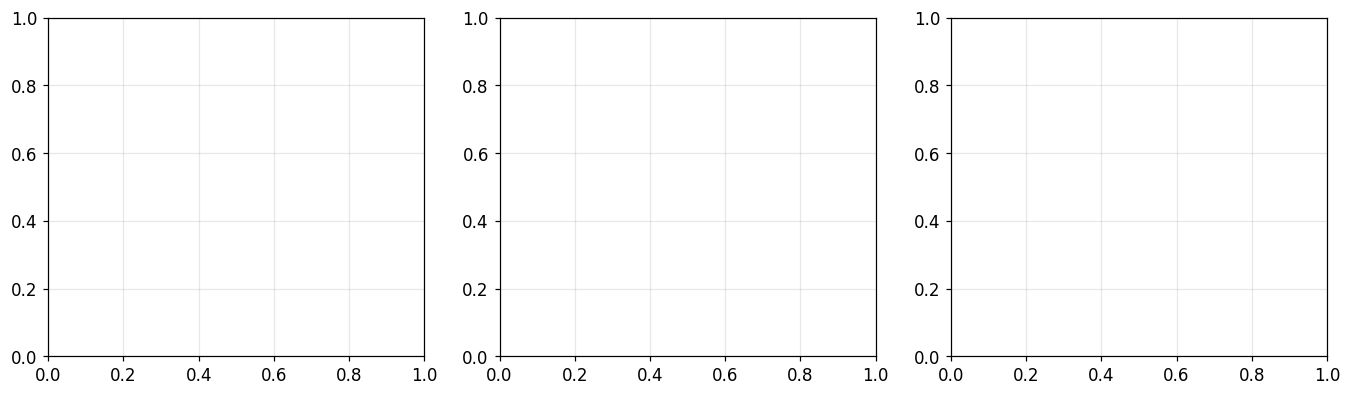

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (tr, vl, name) in zip(axes, [
    (tr_s4, vl_s4, 'S4'), (tr_s4d, vl_s4d, 'S4D'), (tr_mamba, vl_mamba, 'Mamba')
]):
    ax.semilogy(tr, label='train', alpha=0.8)
    ax.semilogy(vl, label='val',   alpha=0.8)
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
    ax.set_title(name); ax.legend()
plt.suptitle('Training Curves — KdV SSM Models', fontsize=13)
plt.tight_layout(); plt.show()

## 10 · Evaluation & Comparison

In [13]:
def predict(model, X):
    model.eval()
    with torch.no_grad():
        Xt = torch.tensor(X, dtype=torch.float32).to(device)
        preds = []
        for i in range(0, len(Xt), 256):
            preds.append(model(Xt[i:i+256]).cpu().numpy())
    return np.concatenate(preds, axis=0)


def compute_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred)**2)
    # Per-sample relative L2 error
    num = np.sqrt(np.sum((y_true - y_pred)**2, axis=-1))
    den = np.sqrt(np.sum(y_true**2, axis=-1)) + 1e-12
    mre = np.mean(num / den)
    return {'mae': mae, 'mse': mse, 'mre': mre}


# Modal-level metrics on test set
results = {}
for name, model in [('S4', s4_model), ('S4D', s4d_model), ('Mamba', mamba_model)]:
    yp = predict(model, X_test)
    m  = compute_metrics(Y_test, yp)
    results[name] = m
    print(f'{name:6s}  MAE={m["mae"]:.4e}  MSE={m["mse"]:.4e}  MRE={m["mre"]*100:.2f}%')

# Field-level reconstruction
print('\n── Field-level MRE per test trajectory ──')
n_win = Nt - lag
for name, model in [('S4', s4_model), ('S4D', s4d_model), ('Mamba', mamba_model)]:
    yp_sc = predict(model, X_test)
    yp_un = scaler.inverse_transform(yp_sc)  # unscale to original POD coefficients
    
    field_pred = yp_un @ Phi.T   # (N_test_windows, Nx)
    
    # Ground truth
    yt_un = scaler.inverse_transform(Y_test)
    field_true = yt_un @ Phi.T
    
    # Per-trajectory MRE
    traj_mre = []
    for ti in range(n_test):
        sl = slice(ti * n_win, (ti+1) * n_win)
        fp = field_pred[sl]
        ft = field_true[sl]
        err = np.sqrt(np.mean((fp - ft)**2)) / (np.sqrt(np.mean(ft**2)) + 1e-12)
        traj_mre.append(err)
    print(f'  {name:6s}  mean field MRE = {np.mean(traj_mre)*100:.2f}% '
          f'(±{np.std(traj_mre)*100:.2f}%)')

S4      MAE=6.6454e-01  MSE=7.1331e-01  MRE=85.08%
S4D     MAE=6.5887e-01  MSE=6.9623e-01  MRE=84.32%
Mamba   MAE=nan  MSE=nan  MRE=nan%

── Field-level MRE per test trajectory ──
  S4      mean field MRE = 79.94% (±8.46%)
  S4D     mean field MRE = 80.05% (±8.12%)
  Mamba   mean field MRE = nan% (±nan%)


## 11 · Reconstruction Visualisation

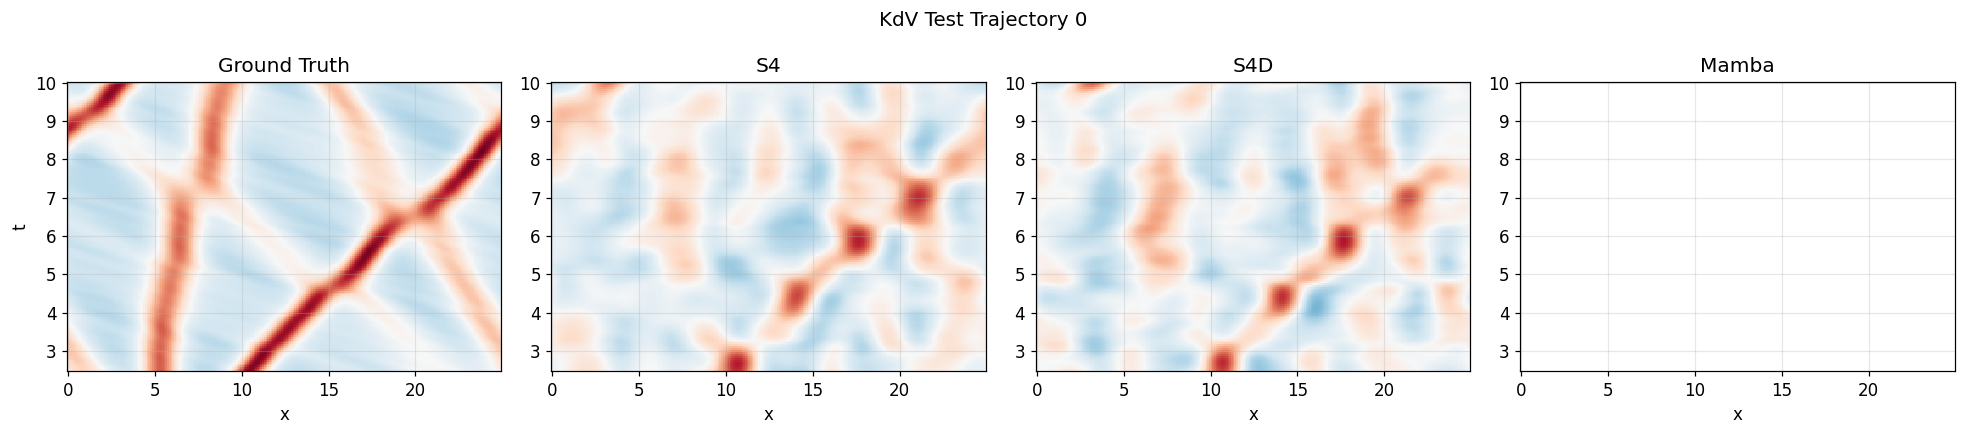

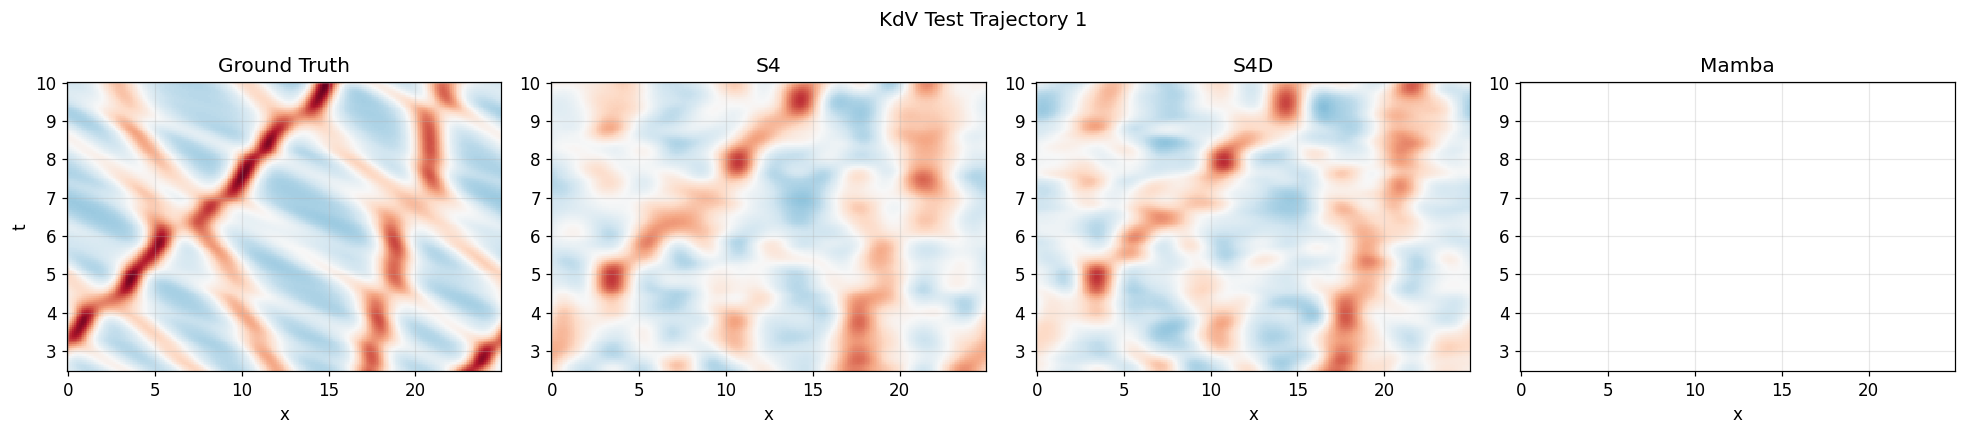

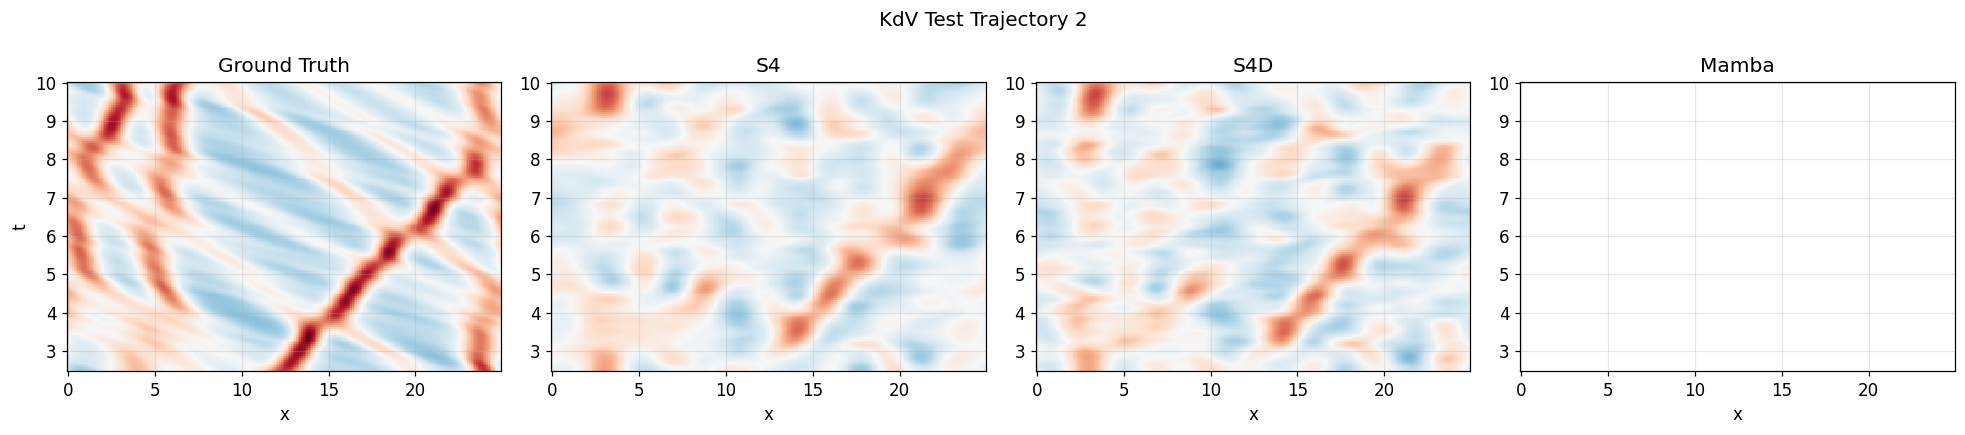

In [14]:
# Show space-time reconstruction for first 3 test trajectories
show_test = [0, 1, 2]
models_dict = {'S4': s4_model, 'S4D': s4d_model, 'Mamba': mamba_model}

for ti in show_test:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    sl = slice(ti * n_win, (ti+1) * n_win)
    t_cut = t_grid[lag:]
    
    # Ground truth
    gt = snaps_test[ti, lag:]
    vmax = np.abs(gt).max()
    axes[0].pcolormesh(x, t_cut, gt, cmap='RdBu_r', shading='auto',
                       vmin=-vmax, vmax=vmax)
    axes[0].set_title('Ground Truth'); axes[0].set_ylabel('t')
    
    for j, (name, model) in enumerate(models_dict.items(), 1):
        yp = predict(model, X_test[sl])
        yp_un = scaler.inverse_transform(yp)
        field = yp_un @ Phi.T
        axes[j].pcolormesh(x, t_cut, field, cmap='RdBu_r', shading='auto',
                           vmin=-vmax, vmax=vmax)
        axes[j].set_title(name)
    
    for ax in axes:
        ax.set_xlabel('x')
    fig.suptitle(f'KdV Test Trajectory {ti}', fontsize=13)
    plt.tight_layout(); plt.show()

## 12 · Animated Reconstruction

Animated comparison of all three SSM models on a random test trajectory, showing the field reconstruction alongside the true sensor lag-window inputs.

ValueError: Axis limits cannot be NaN or Inf

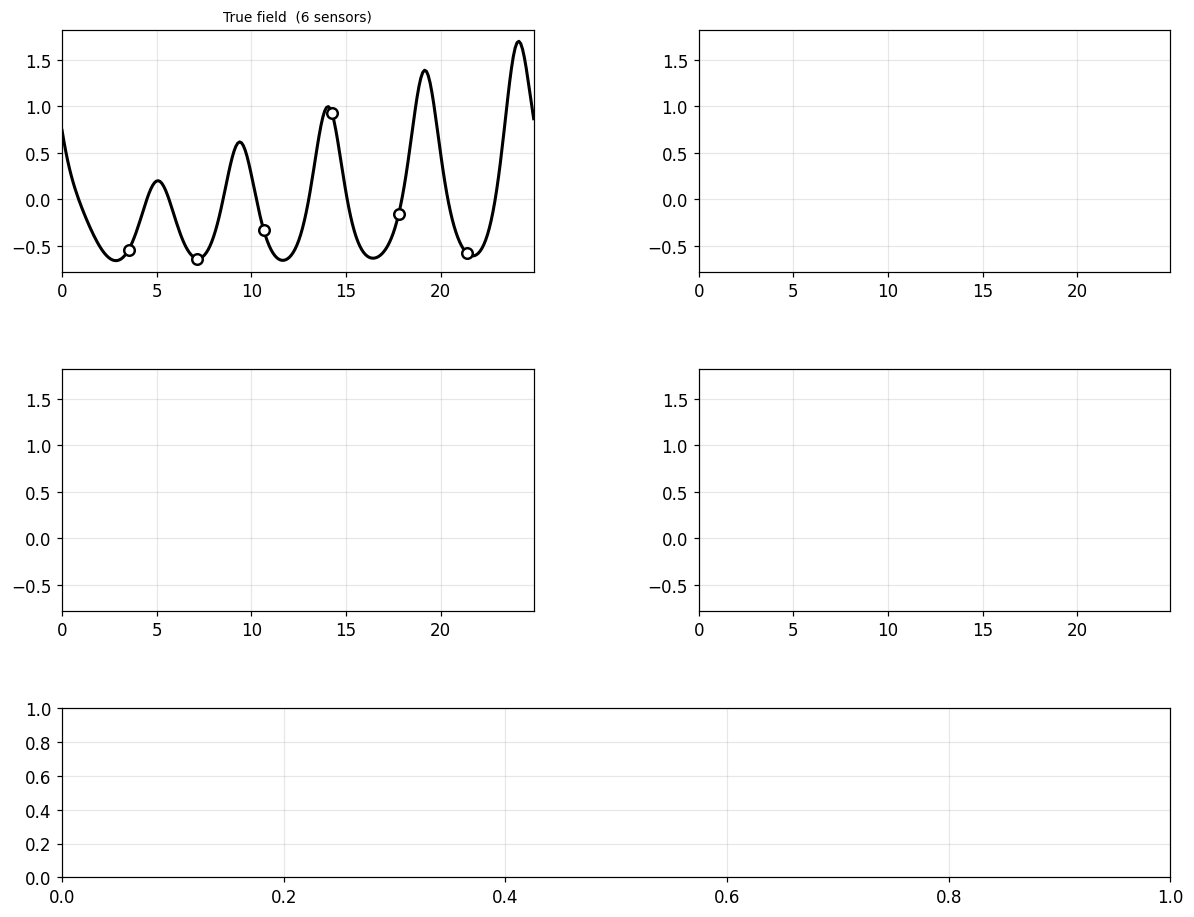

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import matplotlib.gridspec as gridspec

# ── Pick a random test trajectory ─────────────────────────────────────────
traj_idx   = np.random.randint(0, n_test)
frame_step = 1
n_win      = Nt - lag
n_frames   = len(range(0, n_win, frame_step))

# Reconstruct full fields for this trajectory
def _recon_field(model, ti):
    sl = slice(ti * n_win, (ti + 1) * n_win)
    yp = predict(model, X_test[sl])
    return scaler.inverse_transform(yp) @ Phi.T  # (n_win, Nx)

u_true = snaps_test[traj_idx, lag:]                  # (n_win, Nx)
u_s4   = _recon_field(s4_model,  traj_idx)
u_s4d  = _recon_field(s4d_model, traj_idx)
u_mamba = _recon_field(mamba_model, traj_idx)

# Sensor lag windows for this trajectory
sensor_data = X_test.reshape(n_test, n_win, lag, n_sensors)[traj_idx]

sensor_idx = np.asarray(sensor_pos, dtype=int)
lag_steps  = np.arange(-lag + 1, 1)

vmin_a = float(np.min([u_true.min(), u_s4.min(), u_s4d.min(), u_mamba.min()]))
vmax_a = float(np.max([u_true.max(), u_s4.max(), u_s4d.max(), u_mamba.max()]))
pad    = 0.1 * (vmax_a - vmin_a + 1e-12)

# ── Figure layout ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 10))
gs  = gridspec.GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 0.7],
                        hspace=0.45, wspace=0.35)

ax_true  = fig.add_subplot(gs[0, 0])
ax_s4    = fig.add_subplot(gs[0, 1], sharex=ax_true, sharey=ax_true)
ax_s4d   = fig.add_subplot(gs[1, 0], sharex=ax_true, sharey=ax_true)
ax_mamba = fig.add_subplot(gs[1, 1], sharex=ax_true, sharey=ax_true)
ax_sen   = fig.add_subplot(gs[2, :])

axes_field = [ax_true, ax_s4, ax_s4d, ax_mamba]
series     = [u_true, u_s4, u_s4d, u_mamba]
titles     = ['True field', 'S4', 'S4D', 'Mamba']
colors     = ['black', 'tab:blue', 'tab:green', 'tab:orange']

lines             = []
ghost_lines       = []
model_sen_dots    = []
true_sen_overlays = []

for i, (ax, y0, ttl, c) in enumerate(zip(axes_field, series, titles, colors)):
    ln, = ax.plot(x, y0[0], lw=2.0, color=c, zorder=4)
    lines.append(ln)

    if i == 0:
        ghost = None
        ax.set_title(f'{ttl}  ({n_sensors} sensors)', fontsize=9)
    else:
        ghost, = ax.plot(x, u_true[0], lw=1.4, color='black',
                         ls=':', alpha=0.55, zorder=3, label='true')
        ax.legend(fontsize=7, loc='upper right')
        ax.set_title(f'{ttl}  (o=pred, x=true sensor)', fontsize=9)
    ghost_lines.append(ghost)

    dots_model = ax.scatter(
        sensor_x, y0[0, sensor_idx],
        s=48, marker='o', facecolors='white', edgecolors=c, linewidths=1.6, zorder=6,
    )
    model_sen_dots.append(dots_model)

    if i == 0:
        dots_true = None
    else:
        dots_true = ax.scatter(
            sensor_x, u_true[0, sensor_idx],
            s=36, marker='x', c='black', linewidths=1.4, zorder=7,
        )
    true_sen_overlays.append(dots_true)

    ax.set_xlim(float(x[0]), float(x[-1]))
    ax.set_ylim(vmin_a - pad, vmax_a + pad)
    ax.set_xlabel('x'); ax.set_ylabel('u(x, t)')
    ax.grid(alpha=0.25)

# ── Sensor lag-window panel ────────────────────────────────────────────────
sen_colors = plt.cm.tab10(np.linspace(0, 0.9, n_sensors))
sen_lines  = []
w0 = sensor_data[0]
for k in range(n_sensors):
    sl, = ax_sen.plot(lag_steps, w0[:, k], lw=1.8, color=sen_colors[k],
                      label=f's{k}  x={sensor_x[k]:.1f}')
    sen_lines.append(sl)

sen_dots = ax_sen.scatter(
    np.zeros(n_sensors), w0[-1, :],
    s=60, zorder=5, c=sen_colors, edgecolors='black', linewidths=0.8,
)
ax_sen.axvline(0, color='gray', lw=0.8, ls='--')
ax_sen.set_xlim(lag_steps[0], lag_steps[-1])
ax_sen.set_xlabel('Lag step  (0 = current t)')
ax_sen.set_ylabel('Sensor value')
ax_sen.set_title('Input lag window — true sensor readings', fontsize=9)
ax_sen.legend(fontsize=7, ncol=n_sensors + 1, loc='upper left')
ax_sen.grid(alpha=0.25)

sup = fig.suptitle('', fontsize=11)
t_cut_anim = t_grid[lag:]

# ── Update function ────────────────────────────────────────────────────────
def _update(frame_i):
    ti = min(frame_i * frame_step, n_win - 1)

    lines[0].set_ydata(u_true[ti])
    lines[1].set_ydata(u_s4[ti])
    lines[2].set_ydata(u_s4d[ti])
    lines[3].set_ydata(u_mamba[ti])

    for j in [1, 2, 3]:
        ghost_lines[j].set_ydata(u_true[ti])

    model_sen_dots[0].set_offsets(np.column_stack([sensor_x, u_true[ti,   sensor_idx]]))
    model_sen_dots[1].set_offsets(np.column_stack([sensor_x, u_s4[ti,     sensor_idx]]))
    model_sen_dots[2].set_offsets(np.column_stack([sensor_x, u_s4d[ti,    sensor_idx]]))
    model_sen_dots[3].set_offsets(np.column_stack([sensor_x, u_mamba[ti,  sensor_idx]]))
    for j in [1, 2, 3]:
        true_sen_overlays[j].set_offsets(np.column_stack([sensor_x, u_true[ti, sensor_idx]]))

    win = sensor_data[ti]
    for k, sl in enumerate(sen_lines):
        sl.set_ydata(win[:, k])
    sen_dots.set_offsets(np.column_stack([np.zeros(n_sensors), win[-1, :]]))
    s_lo, s_hi = win.min(), win.max()
    s_p = 0.1 * (s_hi - s_lo + 1e-12)
    ax_sen.set_ylim(s_lo - s_p, s_hi + s_p)

    mre_s4    = np.linalg.norm(u_true[ti] - u_s4[ti])    / (np.linalg.norm(u_true[ti]) + 1e-12)
    mre_s4d   = np.linalg.norm(u_true[ti] - u_s4d[ti])   / (np.linalg.norm(u_true[ti]) + 1e-12)
    mre_mamba = np.linalg.norm(u_true[ti] - u_mamba[ti])  / (np.linalg.norm(u_true[ti]) + 1e-12)

    sup.set_text(
        f'KdV: test trajectory {traj_idx} | t = {t_cut_anim[ti]:.2f} | '
        f'MRE  S4={100*mre_s4:.1f}%  S4D={100*mre_s4d:.1f}%  '
        f'Mamba={100*mre_mamba:.1f}%'
    )

    artists = [*lines, *sen_lines, sen_dots, sup]
    artists += [g for g in ghost_lines if g is not None]
    artists += [*model_sen_dots]
    artists += [a for a in true_sen_overlays if a is not None]
    return artists

anim = FuncAnimation(fig, _update, frames=n_frames, interval=80, blit=False)
plt.close(fig)
display(HTML(anim.to_jshtml()))

## 13 · Summary

| Model | Key idea | Computation | Strengths |
|-------|----------|-------------|----------|
| **S4** | Full HiPPO matrix, conv kernel via powers of $\bar{A}$ | $O(LN^2)$ or $O(L\log L)$ with FFT | Optimal long-range memory from HiPPO theory |
| **S4D** | Diagonal HiPPO (eigenvalue decomposition) | $O(LN)$ recurrence, $O(L\log L)$ conv | Efficient; closed-form kernel |
| **Mamba** | Input-dependent $B$, $C$, $\Delta$ (selectivity) | $O(LN)$ recurrence (no conv mode) | Content-aware; adapts to varying sensor signals |